## Scientific Complexity across Polities

For six historical polities, this notebook computes:

- **Scientific complexity**: Shannon entropy of the per-bin top-10 scientific occupations in 50-year bins.
- **Occupation breakdown**: stacked bar chart (log scale) of the top-10 scientific occupations over time, with the complexity curve overlaid.

### 1. Setup

Load the list of scientific occupation labels from the database and define
a simple Shannon entropy function.

In [13]:
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

DB = '../data/humans_clean.sqlite3'


def shannon_entropy(counts, top_n=10):
    """Shannon entropy (bits) of the top-n most frequent items in a Counter."""
    top = [c for _, c in counts.most_common(top_n)]
    total = sum(top)
    if total == 0:
        return np.nan
    p = np.array(top) / total
    return -np.sum(p * np.log2(p))


# Load scientific occupation labels from the database
conn = sqlite3.connect(DB)
SCIENTIFIC_OCCUPATIONS = {
    row[0] for row in conn.execute(
        "SELECT DISTINCT lower(name_en) FROM occupations WHERE meta_occupation = 'scientist'"
    )
}
conn.close()

print(f'Loaded {len(SCIENTIFIC_OCCUPATIONS)} scientific occupation labels')

Loaded 1729 scientific occupation labels


### 2. Entropy formula

$H_t = -\sum_{i=1}^{n} p_{i,t} \log_2(p_{i,t})$

where $p_{i,t} = c_{i,t} / \sum_j c_{j,t}$ is the share of the $i$-th occupation
among the top-$n$ scientific occupations in 50-year bin $t$.
The top-$n$ are selected independently for each bin.

### 3. For each polity: extract scientists, count occupations per bin, compute entropy

Steps per polity:
1. Query all scientists and their occupations from `consolidate`.
2. Assign each individual to a 50-year bin and count their scientific occupations.
3. Keep only complete bins (inside the polity date range) with at least 5 scientists.
4. Compute Shannon entropy of the top-10 occupations per bin.
5. Pick the 10 most common occupations across all bins (for the chart).

In [14]:
polities = [
    ('Kingdom of England',  "(c.polity_name LIKE '%Kingdom of England%')"),
    ('Republic of Venice',  "(c.polity_name LIKE 'Republic of Venice%')"),

]
polity_order = [title for title, _ in polities]

conn = sqlite3.connect(DB)
conn.execute('PRAGMA cache_size=-500000')

focus_data = {}

for title, where in polities:

    # Step 1 — date range and scientist data
    yr_start, yr_end = conn.execute(f'''
        SELECT MIN(c.impact_year), MAX(c.impact_year)
        FROM consolidate c WHERE {where} AND c.impact_year IS NOT NULL
    ''').fetchone()

    df = pd.read_sql(f'''
        SELECT c.occupations, c.impact_year
        FROM consolidate c
        WHERE {where} AND c.occupations IS NOT NULL
          AND c.impact_year IS NOT NULL AND c.is_scientist = 1
    ''', conn)

    # Step 2 — count scientific occupations per 50-year bin
    occ_counts = {}       # bin -> Counter of scientific occupations
    n_scientists = Counter()  # bin -> number of individuals

    for occs_str, year in zip(df['occupations'], df['impact_year']):
        time_bin = ((year + 25) // 50) * 50
        sci_occs = [o.strip().lower() for o in occs_str.split('; ')
                    if o.strip().lower() in SCIENTIFIC_OCCUPATIONS]
        if sci_occs:
            n_scientists[time_bin] += 1
            occ_counts.setdefault(time_bin, Counter()).update(sci_occs)

    # Step 3 — keep only complete bins with enough data
    bins = sorted(b for b in occ_counts
                  if b - 25 >= yr_start and b + 24 <= yr_end
                  and n_scientists[b] >= 5)

    # Step 4 — entropy per bin
    entropy = [shannon_entropy(occ_counts[b]) for b in bins]

    # Step 5 — pick the 10 most common occupations across all bins (for the chart)
    total_counts = Counter()
    for b in bins:
        for occ, n in occ_counts[b].most_common(10):
            total_counts[occ] += n
    top10 = [occ for occ, _ in total_counts.most_common(10)]

    # Raw counts per bin for the top-10 occupations
    raw_counts = {occ: [occ_counts[b].get(occ, 0) for b in bins] for occ in top10}

    focus_data[title] = dict(
        yr_start=yr_start, yr_end=yr_end, bins=bins,
        entropy=entropy, top10=top10, raw_counts=raw_counts,
    )

    print(f'{title} ({yr_start}\u2013{yr_end}): {len(bins)} bins, '
          f'{sum(n_scientists[b] for b in bins)} scientists')

conn.close()

Kingdom of England (936–1708): 12 bins, 964 scientists
Republic of Venice (735–1796): 9 bins, 674 scientists


In [15]:
rows = []
for title in polity_order:
    d = focus_data[title]
    for i, b in enumerate(d['bins']):
        row = {'polity': title, 'bin': b, 'entropy': round(d['entropy'][i], 3)}
        for occ in d['top10']:
            row[occ] = d['raw_counts'][occ][i]
        rows.append(row)

df_complexity = pd.DataFrame(rows)
print(f"Scientific complexity data for {len(polity_order)} polities:")
df_complexity

Scientific complexity data for 2 polities:


,polity,bin,entropy,theologian,historian,philosopher,mathematician,university teacher,linguist,astronomer,bible translator,chronicler,academic,philologist,teacher,cartographer,physicist
0,Kingdom of England,1100,2.289,3,6,2,1,0,0.0,1,0.0,2.0,0.0,NaN,NaN,NaN,NaN
1,Kingdom of England,1150,2.761,10,11,7,0,0,0.0,2,0.0,3.0,0.0,NaN,NaN,NaN,NaN
2,Kingdom of England,1200,2.826,17,11,8,2,3,2.0,3,0.0,6.0,0.0,NaN,NaN,NaN,NaN
3,Kingdom of England,1250,2.990,9,4,7,2,4,1.0,1,0.0,1.0,0.0,NaN,NaN,NaN,NaN
4,Kingdom of England,1300,2.755,13,7,13,2,3,1.0,0,0.0,6.0,0.0,NaN,NaN,NaN,NaN
5,Kingdom of England,1350,2.703,19,3,8,5,4,0.0,5,1.0,1.0,0.0,NaN,NaN,NaN,NaN
6,Kingdom of England,1400,2.560,20,5,6,2,0,1.0,4,1.0,2.0,2.0,NaN,NaN,NaN,NaN
7,Kingdom of England,1450,2.757,7,12,0,1,0,1.0,1,0.0,5.0,0.0,NaN,NaN,NaN,NaN
8,Kingdom of England,1500,2.725,14,3,2,2,1,2.0,1,1.0,0.0,2.0,NaN,NaN,NaN,NaN
9,Kingdom of England,1550,3.109,25,21,5,8,15,14.0,2,8.0,2.0,8.0,NaN,NaN,NaN,NaN


### 4. Stacked counts of scientific occupations (log scale) with complexity curve

Raw number of scientists in each top-10 occupation per 50-year bin, with the Shannon
entropy (complexity) overlaid on the right axis.

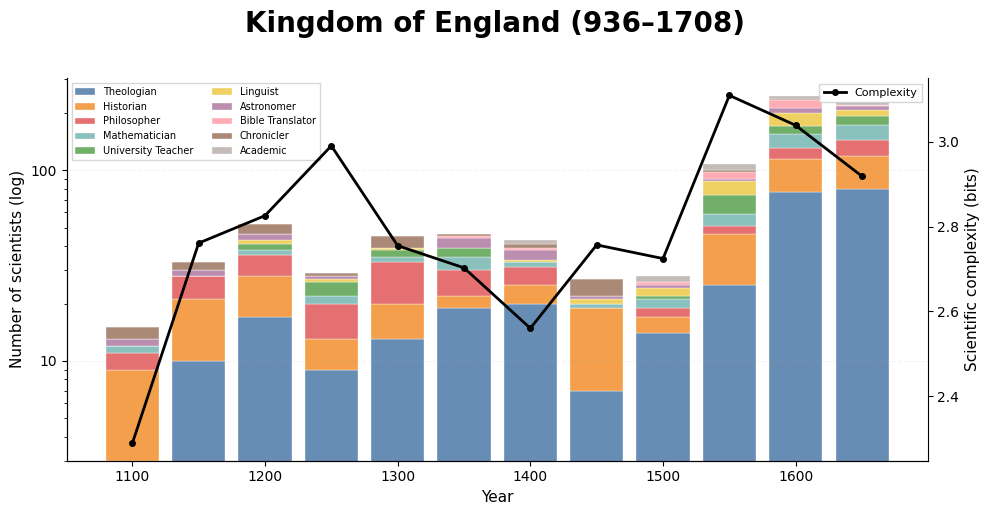

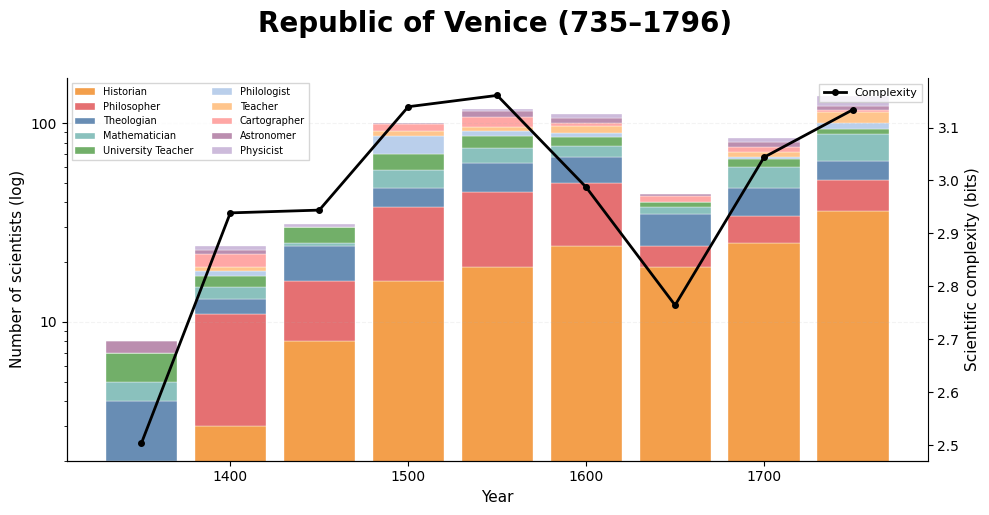

In [16]:
import matplotlib.ticker as ticker

PALETTE = [
    '#4e79a7', '#f28e2b', '#e15759', '#76b7b2', '#59a14f',
    '#edc948', '#b07aa1', '#ff9da7', '#9c755f', '#bab0ac',
    '#aec7e8', '#ffbb78', '#ff9896', '#c5b0d5', '#c49c94',
]

# Build a global occupation → color mapping so colors are consistent across polities
all_occs = []
for title in polity_order:
    for occ in focus_data[title]['top10']:
        if occ not in all_occs:
            all_occs.append(occ)
occ_color = {occ: PALETTE[i % len(PALETTE)] for i, occ in enumerate(all_occs)}

for polity_name in polity_order:
    d = focus_data[polity_name]
    bins = d['bins']
    top10 = d['top10']

    fig, ax = plt.subplots(figsize=(10, 5))

    bottom = np.zeros(len(bins))
    for occ in top10:
        vals = np.array(d['raw_counts'][occ], dtype=float)
        ax.bar(bins, vals, bottom=bottom, width=40, color=occ_color[occ],
               alpha=0.85, label=occ.title(), edgecolor='white', linewidth=0.3)
        bottom += vals

    ax.set_yscale('log')
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x)}' if x >= 1 else ''))
    ax.yaxis.set_minor_formatter(ticker.NullFormatter())
    ax.set_ylabel('Number of scientists (log)', fontsize=11)
    ax.set_xlabel('Year', fontsize=11)
    ax.tick_params(labelsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', alpha=0.15, linestyle='--')

    ax_r = ax.twinx()
    ax_r.plot(bins, d['entropy'], '-o', color='black', linewidth=2,
              markersize=4, zorder=5, label='Complexity')
    ax_r.set_ylabel('Scientific complexity (bits)', fontsize=11)
    ax_r.tick_params(labelsize=10)
    ax_r.spines['top'].set_visible(False)
    ax_r.legend(fontsize=8, loc='upper right', frameon=True,
                fancybox=False, edgecolor='#cccccc')

    ax.legend(fontsize=7, loc='upper left', ncol=2, frameon=True,
              fancybox=False, edgecolor='#cccccc')

    fig.suptitle(f"{polity_name} ({d['yr_start']}–{d['yr_end']})",
                 fontsize=20, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

### 5. Individual lists

- Theologians in the Kingdom of England
- Historians in the Republic of Venice

In [17]:
conn = sqlite3.connect(DB)

df_theologians = pd.read_sql("""
    SELECT c.name_en, c.impact_year
    FROM consolidate c
    WHERE c.polity_name LIKE '%Kingdom of England%'
      AND c.is_scientist = 1
      AND lower(c.occupations) LIKE '%theologian%'
    ORDER BY c.impact_year
""", conn)
print(f"Theologians in Kingdom of England: {len(df_theologians)}")
display(df_theologians)

df_historians = pd.read_sql("""
    SELECT c.name_en, c.impact_year
    FROM consolidate c
    WHERE c.polity_name LIKE 'Republic of Venice%'
      AND c.is_scientist = 1
      AND lower(c.occupations) LIKE '%historian%'
    ORDER BY c.impact_year
""", conn)
print(f"\nHistorians in Republic of Venice: {len(df_historians)}")
display(df_historians)

conn.close()

Theologians in Kingdom of England: 352


,name_en,impact_year
0,Robert of Halifax,NaN
1,John Beverley,NaN
2,John Clipston,NaN
3,Richard Billingham,NaN
4,William Butler,NaN
...,...,...
347,Thomas Woolston,1703.0
348,Joseph Bingham,1703.0
349,John Toland,1705.0
350,Edmund Chishull,1705.0



Historians in Republic of Venice: 190


,name_en,impact_year
0,None,NaN
1,Thomas the Archdeacon,1235.0
2,Andrea Dandolo,1341.0
3,Rafaino Caresini,1349.0
4,Lorenzo de Monacis,1386.0
...,...,...
185,Giuseppe Ronchetti,1787.0
186,Vincenzo Formaleoni,1787.0
187,Tripo Smeća,1790.0
188,Andrija Ciccarelli,1794.0


In [20]:
df_theologians.dropna()

,name_en,impact_year
11,Dunstan,944.0
12,Ælfric of Eynsham,985.0
13,Gilbert Crispin,1090.0
14,Stephen Harding,1094.0
15,Robert Pullen,1115.0
...,...,...
347,Thomas Woolston,1703.0
348,Joseph Bingham,1703.0
349,John Toland,1705.0
350,Edmund Chishull,1705.0


In [19]:
df_historians.dropna()

,name_en,impact_year
1,Thomas the Archdeacon,1235.0
2,Andrea Dandolo,1341.0
3,Rafaino Caresini,1349.0
4,Lorenzo de Monacis,1386.0
5,Antonio Morosini,1403.0
...,...,...
185,Giuseppe Ronchetti,1787.0
186,Vincenzo Formaleoni,1787.0
187,Tripo Smeća,1790.0
188,Andrija Ciccarelli,1794.0
